In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

# V4L2 gives each camera TWO /dev/video* nodes: an even capture node and an odd
# metadata node that cannot stream. VideoCapture indexes nodes, not cameras, so
# an odd index fails with "can't open camera by index" + "VIDIOC_QBUF: Bad file
# descriptor" - OpenCV then falls back to the FFMPEG backend, which usually
# still works but ignores every CAP_PROP_* setting (no exposure control).
# On this machine: 0 = built-in, 2 = IR, 4 = C270 USB webcam.
# (macOS enumerates cameras rather than nodes, which is why VideoCapture(1)
# was right on the Mac and wrong here.)
CAM_INDEX = 4

def open_camera(index=CAM_INDEX):
    """Open a V4L2 capture node, or fail with the indices that actually stream."""
    cap = cv2.VideoCapture(index, cv2.CAP_V4L2)   # pinned: no silent fallback
    if cap.isOpened() and cap.read()[0]:
        return cap
    cap.release()

    working = []
    for i in range(10):
        probe = cv2.VideoCapture(i, cv2.CAP_V4L2)
        if probe.isOpened() and probe.read()[0]:
            working.append(i)
        probe.release()
    raise RuntimeError("index {0} won't stream; working indices: {1}".format(index, working))

# 1: camera intrinsics calibration

In [14]:
# ChArUco board:
COLS, ROWS = 6, 8                       # squares across, down
square_len = 0.030                      # 30 mm squares, in metres
marker_len = 0.0225                     # 22.5 mm markers (must be < square)
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_100)
board = cv2.aruco.CharucoBoard((COLS, ROWS), square_len, marker_len, aruco_dict)
MARGIN = 60
cv2.imwrite("charuco_6x8.png", board.generateImage((960 + 2 * MARGIN, 1280 + 2 * MARGIN), marginSize=MARGIN))

True

In [15]:
def calibrate_camera_intrinsic(image_filenames):
    detector = cv2.aruco.CharucoDetector(board)   # sub-pixel refines internally
    all_obj, all_img = [], []
    image_resolution = None

    for img_file in sorted(image_filenames):
        img = cv2.imread(img_file)
        if img is None:
            print("=> unreadable: {0}".format(img_file))
            continue
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        wh = img_gray.shape[:2][::-1]   # converts numpy (h, w) to (w, h)
        if image_resolution is None:
            image_resolution = wh
        elif wh != image_resolution:
            raise ValueError("{0}: size {1} != {2}".format(img_file, wh, image_resolution))

        corners, ids, _, _ = detector.detectBoard(img_gray)
        n = 0 if corners is None else len(corners)

        if n < 6:                       # too few (or none) to pose the board - skip
            continue
        
        objPoints, imgPoints = board.matchImagePoints(corners, ids)
        all_obj.append(objPoints)
        all_img.append(imgPoints)

    if len(all_obj) < 4:
        raise RuntimeError("only {0} usable views; aim for 20+".format(len(all_obj)))

    # Default 5-coefficient model (k1,k2,p1,p2,k3). CALIB_RATIONAL_MODEL adds 3
    # more radial terms but overfits unless many views reach the image border.
    (ret, camera_matrix, distortion_coefficients,
     rotation_vectors, translation_vectors) = cv2.calibrateCamera(
        all_obj, all_img, image_resolution, None, None)

    print('views used:', len(all_obj))
    print('ret (RMS reprojection, px):', ret)   # want < 0.5
    print('camera_matrix:', camera_matrix)
    print('distortion_coefficients:', distortion_coefficients.ravel())
    return True, camera_matrix, distortion_coefficients

def detect_calib_board(image_rgb, camera_matrix, dist_coeffs):
    output_img_rgb = image_rgb.copy()
    grey = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    detector = cv2.aruco.CharucoDetector(board)
    corners, chIds, mCorners, mIds = detector.detectBoard(grey)
    if corners is None or len(corners) < 4:
        print('Error: Could not identify the calibration board in the image!')
        return False, None, None, output_img_rgb

    # OpenCV 5 returns flat (N,2)/(N,) arrays; the drawing helpers want (N,1,*)
    if mIds is not None and len(mIds):
        cv2.aruco.drawDetectedMarkers(output_img_rgb, mCorners,
                                      np.asarray(mIds).reshape(-1, 1))
    cv2.aruco.drawDetectedCornersCharuco(output_img_rgb,
                                         np.asarray(corners).reshape(-1, 1, 2),
                                         np.asarray(chIds).reshape(-1, 1))

    objPoints, imgPoints = board.matchImagePoints(corners, chIds)
    ret_val, board_rvec_rdg, board_tvec = cv2.solvePnP(
        objPoints, imgPoints, camera_matrix, dist_coeffs)
    if not ret_val:
        print('Error: Could not identity the pose of the calibration board in the image!')
        return False, None, None, output_img_rgb

    print('Board rvec: ')
    print(board_rvec_rdg)
    print('Board tvec: ')
    print(board_tvec)

    length_of_axis = 0.05          # metres; ~1.7 squares, visible at 30 mm pitch
    cv2.drawFrameAxes(output_img_rgb, camera_matrix, dist_coeffs,
                      board_rvec_rdg, board_tvec, length_of_axis)
    plt.imshow(output_img_rgb)
    plt.show()
    return True, board_rvec_rdg, board_tvec, output_img_rgb

In [16]:
image_files = sorted(glob.glob("board_images/*.jpeg"))
calibrated, camera_matrix, distortion_coefficients = calibrate_camera_intrinsic(image_files)

# Cache it so later cells (and other scripts) don't have to recalibrate:
np.savez("camera_intrinsics.npz",
         camera_matrix=camera_matrix, dist_coeffs=distortion_coefficients)
# reload with: d = np.load("camera_intrinsics.npz");
#              camera_matrix, distortion_coefficients = d["camera_matrix"], d["dist_coeffs"]

views used: 21
ret (RMS reprojection, px): 0.35075352046796404
camera_matrix: [[1.41228973e+03 0.00000000e+00 4.66571315e+02]
 [0.00000000e+00 1.41310687e+03 3.53707259e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
distortion_coefficients: [ 1.25626926e-01 -4.78803961e-01  4.90451879e-03 -7.51391442e-03
  5.36255851e+00]


Board rvec: 
[[ 0.2864777]
 [-0.2526747]
 [ 1.5385224]]
Board tvec: 
[[ 0.12046235]
 [-0.08155895]
 [ 0.50497192]]


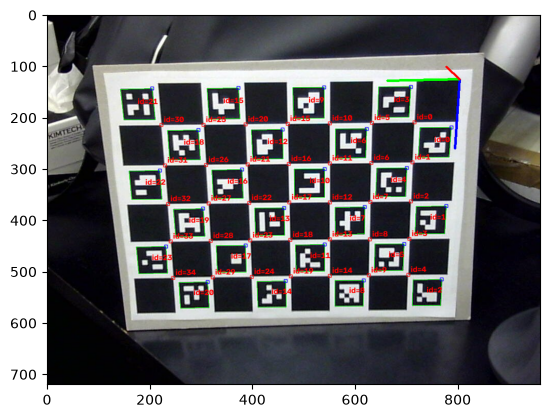

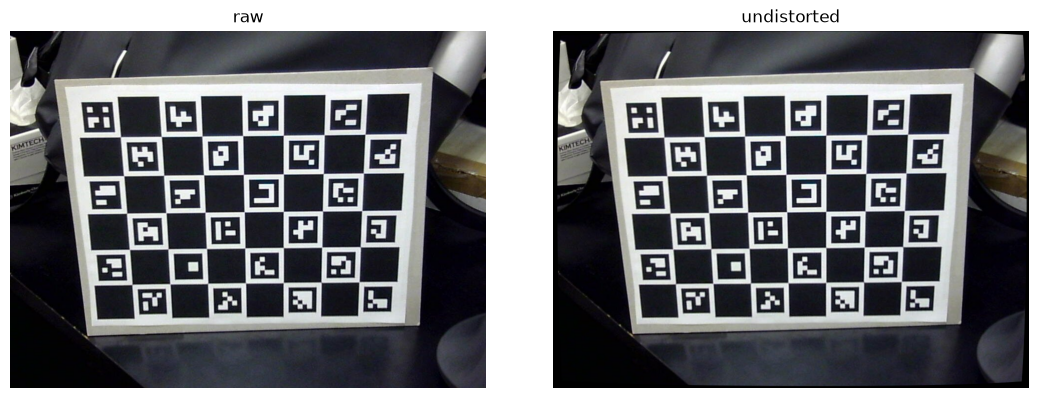

In [17]:
# Sanity check: board pose on one view + before/after undistortion
img_rgb = cv2.cvtColor(cv2.imread(image_files[1]), cv2.COLOR_BGR2RGB)
ok, rvec, tvec, drawn = detect_calib_board(img_rgb, camera_matrix, distortion_coefficients)

undistorted = cv2.undistort(img_rgb, camera_matrix, distortion_coefficients)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(img_rgb);      ax[0].set_title("raw");         ax[0].axis("off")
ax[1].imshow(undistorted);  ax[1].set_title("undistorted"); ax[1].axis("off")
plt.tight_layout(); plt.show()

In [18]:
# Colour segmentation in HSV.
#
# OpenCV hue is 0-179 (degrees / 2), S and V are 0-255. The S/V floors are what
# keep white walls and dark corners out of the mask - tune those before hue.
# Red straddles hue 0, so it needs two windows OR'd together; green and blue
# sit mid-range and need only one.
HSV_RANGES = {
    "red":   [((  0, 120, 70), ( 10, 255, 255)),    # low side of the wrap
              ((170, 120, 70), (179, 255, 255))],   # high side
    "green": [(( 40,  80, 60), ( 85, 255, 255))],
    "blue":  [((100,  80, 60), (130, 255, 255))],
}

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

def colour_mask(frame_bgr, colour):
    """Binary mask (0 / 255) of one named colour in HSV_RANGES."""
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    mask = None
    for lo, hi in HSV_RANGES[colour]:
        m = cv2.inRange(hsv, np.array(lo, np.uint8), np.array(hi, np.uint8))
        mask = m if mask is None else cv2.bitwise_or(mask, m)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)    # drop speckle
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)   # fill pinholes
    return mask

def largest_blob(mask, min_area=200):
    """Biggest contour in a mask, or None. This is what you feed to the SVD pose cell."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    cnt = max(contours, key=cv2.contourArea)
    return cnt if cv2.contourArea(cnt) >= min_area else None

In [19]:
# Live three-colour view: original + R/G/B masks tiled in one window.
# Each mask is tinted its own colour so you can tell at a glance which is which.
TINTS = {"red": (0, 0, 255), "green": (0, 255, 0), "blue": (255, 0, 0)}   # BGR

cap = open_camera()
while True:
    ret, frame = cap.read()
    if not ret:
        break

    panels = [frame]
    for colour, tint in TINTS.items():
        mask = colour_mask(frame, colour)
        panel = np.zeros_like(frame)
        panel[mask > 0] = tint                       # mask -> colour, for display only
        cnt = largest_blob(mask)
        if cnt is not None:
            M = cv2.moments(cnt)
            cx, cy = int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])
            cv2.circle(panel, (cx, cy), 5, (255, 255, 255), -1)
            cv2.drawContours(frame, [cnt], -1, tint, 2)
        cv2.putText(panel, colour, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,) * 3, 2)
        panels.append(panel)

    top = np.hstack(panels[:2])
    bottom = np.hstack(panels[2:])
    cv2.imshow("colour masks", np.vstack([top, bottom]))
    if cv2.waitKey(1) & 0xFF == 27:  # ESC
        break
cap.release()
cv2.destroyAllWindows()

[ WARN:0@10766.234] global cap_v4l.cpp:804 requestBuffers VIDEOIO(V4L2:/dev/video4): failed VIDIOC_REQBUFS: errno=19 (No such device)


In [20]:
# Tuner: click your object in the live feed to read its HSV, then widen
# HSV_RANGES around what you see. Beats guessing numbers.
samples = []

def on_click(event, x, y, flags, hsv_holder):
    if event == cv2.EVENT_LBUTTONDOWN:
        patch = hsv_holder[0][max(y-2, 0):y+3, max(x-2, 0):x+3].reshape(-1, 3)
        h, s, v = patch.mean(axis=0)
        samples.append((h, s, v))
        print("H={0:5.1f}  S={1:5.1f}  V={2:5.1f}".format(h, s, v))

cap = open_camera()
hsv_holder = [None]
cv2.namedWindow("click to sample")
cv2.setMouseCallback("click to sample", on_click, hsv_holder)
while True:
    ret, frame = cap.read()
    if not ret:
        break
    hsv_holder[0] = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    cv2.imshow("click to sample", frame)
    if cv2.waitKey(1) & 0xFF == 27:  # ESC
        break
cap.release()
cv2.destroyAllWindows()

if samples:
    arr = np.array(samples)
    print("\nsampled min:", arr.min(axis=0).round(1))
    print("sampled max:", arr.max(axis=0).round(1))
    # Rule of thumb: hue +-10 around the sampled range, S/V floors ~30 below
    # the minimum you saw, ceilings at 255.

[ WARN:0@10766.243] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video4): can't open camera by index
[ WARN:0@10766.243] global cap.cpp:475 open VIDEOIO(V4L2): backend is generally available but can't be used to capture by index
[ WARN:0@10766.704] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video1): can't open camera by index
[ WARN:0@10766.704] global cap.cpp:475 open VIDEOIO(V4L2): backend is generally available but can't be used to capture by index
[ WARN:0@10767.226] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video3): can't open camera by index
[ WARN:0@10767.226] global cap.cpp:475 open VIDEOIO(V4L2): backend is generally available but can't be used to capture by index
[ WARN:0@10767.226] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video4): can't open camera by index
[ WARN:0@10767.226] global cap.cpp:475 open VIDEOIO(V4L2): backend is generally available but can't be used to capture by index
[ WARN:0@10767.226] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video5): can't

RuntimeError: index 4 won't stream; working indices: [0, 2]

In [ ]:
# Live SVD drone pose estimator
cap = open_camera()
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (12, 12))
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 90, 255, cv2.THRESH_BINARY)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cnt = max(contours, key=cv2.contourArea) # pick largest contour by area

        M = cv2.moments(cnt) # contour centroid
        if M["m00"] != 0:
            centroid_x = int(M["m10"] / M["m00"])
            centroid_y = int(M["m01"] / M["m00"])
        else:
            centroid_x = centroid_y = None

        print("centroid:", (centroid_x, centroid_y))

        if cv2.contourArea(cnt) > 200:
            fill = np.zeros_like(gray)
            cv2.drawContours(fill, [cnt], -1, 255, cv2.FILLED)
            ys, xs = np.nonzero(fill)
            pts = np.column_stack((xs, ys)).astype(float)
            center = pts.mean(axis=0)
            _, S, Vt = np.linalg.svd(pts - center, full_matrices=False)
            major = Vt[0]                                  # in-plane axis (image coords)
            alpha = np.arccos(np.clip(S[1] / S[0], 0, 1))  # tilt: minor/major = cos(alpha)
            normal = np.array([-np.sin(alpha) * major[1],  # disk-plane normal (3D)
                                np.sin(alpha) * major[0],
                                np.cos(alpha)])
            proj = (pts - center) @ major
            L = (proj.max() - proj.min()) / 2              # draw length from blob extent
            c = center.astype(int)
            cv2.line(frame, tuple((center - major * L).astype(int)),
                            tuple((center + major * L).astype(int)), (255, 0, 0), 2)
            cv2.line(frame, tuple(c),
                            tuple((center + normal[:2] * L).astype(int)), (0, 255, 0), 2)
            cv2.circle(frame, tuple(c), 4, (0, 0, 255), -1)
            image = cv2.circle(frame, (centroid_x, centroid_y), 4, (100, 0, 255), -1)


    cv2.imshow("pose", frame)
    if cv2.waitKey(1) & 0xFF == 27:  # ESC
        break
cap.release()
cv2.destroyAllWindows()

2026-07-25 22:16:41.361 Python[98236:6341742] ApplePersistenceIgnoreState: Existing state will not be touched. New state will be written to /var/folders/63/7cv2q0897zv367k7c1bdmp500000gn/T/org.python.python.savedState


centroid: (395, 523)
centroid: (850, 436)
centroid: (904, 470)
centroid: (908, 479)
centroid: (903, 481)
centroid: (903, 481)
centroid: (903, 481)
centroid: (903, 481)
centroid: (902, 480)
centroid: (904, 481)
centroid: (901, 480)
centroid: (904, 480)
centroid: (903, 480)
centroid: (903, 481)
centroid: (905, 481)
centroid: (905, 482)
centroid: (906, 482)
centroid: (906, 483)
centroid: (905, 483)
centroid: (907, 483)
centroid: (943, 507)
centroid: (910, 488)
centroid: (943, 507)
centroid: (942, 507)
centroid: (943, 508)
centroid: (943, 508)
centroid: (942, 505)
centroid: (943, 507)
centroid: (942, 508)
centroid: (942, 509)
centroid: (942, 510)
centroid: (942, 511)
centroid: (942, 511)
centroid: (942, 512)
centroid: (942, 512)
centroid: (943, 512)
centroid: (942, 513)
centroid: (942, 513)
centroid: (942, 514)
centroid: (942, 514)
centroid: (942, 514)
centroid: (942, 512)
centroid: (942, 511)
centroid: (942, 510)
centroid: (942, 509)
centroid: (942, 509)
centroid: (942, 508)
centroid: (94

KeyboardInterrupt: 

: 